## Módulo 3. Cálculo de Radiación Solar a partir de Datos Geomáticos

En este módulo se utilizan herramientas de **QGIS Processing**, **GDAL**, **GRASS GIS**, `geopandas` y `rasterio` para resolver dos problemas geomáticos:

- Calcular una **ruta más corta** sobre una red vectorial.
- Estimar la **radiación solar**, las **Horas Sol Pico (PSH)** y la **producción solar diaria** a partir de un modelo digital de elevación.

### **Análisis de redes: ruta más corta entre dos puntos**

Un **análisis de redes** permite estudiar desplazamientos sobre elementos lineales, como calles, caminos, tuberías o ríos. En este ejemplo se calcula la **ruta más corta** entre un punto inicial y un punto final usando una capa de líneas.

El algoritmo `native:shortestpathpointtopoint` de QGIS necesita:

- Una capa de red: `redes.gpkg`.
- Un punto inicial y un punto final.
- Un archivo de salida donde se guardará la ruta: `ruta.gpkg`.

Se usa el proyecto `analisis_redes.qgz` porque ayuda a QGIS a interpretar correctamente el contexto espacial del análisis, como capas, CRS y transformaciones de coordenadas.

In [1]:
import subprocess

cmd = [
    "docker", "exec", "fastapi-qgis",
    "qgis_process",
    "run",
    "native:shortestpathpointtopoint",
    "--PROJECT_PATH=/app/project/analisis_redes.qgz",
    "--",
    "INPUT=/app/data/redes.gpkg",
    "START_POINT=-71.574229,-13.516067 [EPSG:4326]",
    "END_POINT=-71.572639,-13.517401 [EPSG:4326]",
    "OUTPUT=/app/output/ruta.gpkg",
]

result = subprocess.run(cmd, capture_output=True, text=True)

print("returncode:", result.returncode)
print("stdout:", result.stdout)
print("stderr:", result.stderr)

returncode: 0
stdout: 
----------------
Inputs
----------------

END_POINT:	-71.572639,-13.517401 [EPSG:4326]
INPUT:	/app/data/redes.gpkg
OUTPUT:	/app/output/ruta.gpkg
START_POINT:	-71.574229,-13.516067 [EPSG:4326]


Building graph…
0...10...20...30...40...50...60...70...80...90...100 - done.
Calculating shortest path…
Writing results…

----------------
Results
----------------

OUTPUT:	/app/output/ruta.gpkg
TRAVEL_COST:	328.2763079313715

stderr: QStandardPaths: XDG_RUNTIME_DIR not set, defaulting to '/tmp/runtime-root'



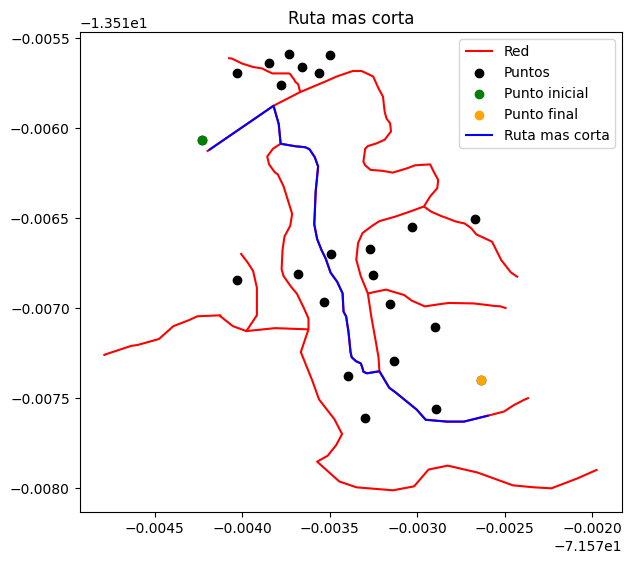

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

red = gpd.read_file("../docker/fastapi-qgis/data/redes.gpkg")
point = gpd.read_file("../docker/fastapi-qgis/data/puntos.gpkg")
rute = gpd.read_file("../docker/fastapi-qgis/output/ruta.gpkg")
point_init = point[
    (point["lat"]==-13.516067) &
    (point["lon"]==-71.574229)
]
point_end = point[
    (point["lat"]==-13.517401) &
    (point["lon"]==-71.572639)
]

fig, ax = plt.subplots(figsize=(7,7))

red.plot(ax=ax, color="red", label="Red")
point.plot(ax=ax, color="black", label="Puntos")
point_init.plot(ax=ax, color="green", label="Punto inicial")
point_end.plot(ax=ax, color="orange", label="Punto final")
rute.plot(ax=ax, color="blue", label="Ruta mas corta")

ax.set_title("Ruta mas corta")
ax.legend()

plt.show()


### **Cálculo de radiación solar a partir de un DEM**

Para estimar la radiación solar se parte de un **Modelo Digital de Elevación (DEM)**. Un DEM es un raster donde cada píxel representa una altura del terreno.

A partir del DEM se calculan tres variables importantes:

- **Pendiente (`slope`)**: indica la inclinación del terreno.
- **Orientación (`aspect`)**: indica hacia dónde mira la ladera.
- **Radiación global (`glob_rad`)**: energía solar recibida por unidad de superficie durante un día.

El flujo de trabajo es:

1. Asignar el CRS correcto al DEM.
2. Calcular pendiente y orientación con `grass:r.slope.aspect`.
3. Calcular insolación y radiación global con `grass:r.sun.insoltime`.

La salida `insolacion.tif` representa horas de sol, mientras que `radiacion_global_diaria.tif` representa radiación en `Wh/m²/día`.

In [4]:
import subprocess

CONTAINER = "fastapi-qgis"
DEM = "/app/data/module03/MDE_talud_modificado.tif"
DEM_CRS = "EPSG:25829"  # ETRS89 / UTM 29N

SLOPE = "/app/output/radiacion_solar/slope.tif"
ASPECT = "/app/output/radiacion_solar/aspect.tif"
INSOLATION = "/app/output/radiacion_solar/insolacion.tif"
GLOBAL_RADIATION = "/app/output/radiacion_solar/radiacion_global_diaria.tif"

DAY_OF_YEAR = 295
TIME_STEP_HOURS = 0.5


def run_cmd(step_name, cmd, expected_outputs=()):
    print(f"\n=== {step_name} ===")

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        print("ERROR")
        print(result.stderr)
        raise RuntimeError(f"Falló: {step_name}")

    for output_path in expected_outputs:
        check = subprocess.run(["docker", "exec", CONTAINER, "test", "-f", output_path])
        if check.returncode != 0:
            raise FileNotFoundError(f"No se generó: {output_path}")

    print("OK")


#Asignar CRS al DEM original
assign_crs_cmd = [
    "docker", "exec", CONTAINER,
    "qgis_process", "run", "gdal:assignprojection",
    "--",
    f"INPUT={DEM}",
    f"CRS={DEM_CRS}",
    f"OUTPUT={DEM}",
]

# Pendiente y orientación del talud.
slope_cmd = [
    "docker", "exec", CONTAINER,
    "qgis_process", "run", "grass:r.slope.aspect",
    "--",
    f"elevation={DEM}",
    f"slope={SLOPE}",
    f"aspect={ASPECT}",
]

# Insolación y radiación global diaria. insol_time (h) y glob_rad (Wh/m2/día).
rsun_cmd = [
    "docker", "exec", CONTAINER,
    "qgis_process", "run", "grass:r.sun.insoltime",
    "--",
    f"elevation={DEM}",
    f"slope={SLOPE}",
    f"aspect={ASPECT}",
    f"insol_time={INSOLATION}",
    f"glob_rad={GLOBAL_RADIATION}",
    f"day={DAY_OF_YEAR}",
    f"step={TIME_STEP_HOURS}",
]

run_cmd("Paso 0 - Asignar CRS al DEM", assign_crs_cmd)
run_cmd("Paso 1 - Calcular slope y aspect", slope_cmd, expected_outputs=(SLOPE, ASPECT))
run_cmd("Paso 2 - Calcular insolación y radiación global", rsun_cmd, expected_outputs=(INSOLATION, GLOBAL_RADIATION),)


=== Paso 0 - Asignar CRS al DEM ===
OK

=== Paso 1 - Calcular slope y aspect ===
OK

=== Paso 2 - Calcular insolación y radiación global ===
OK


### **Horas Sol Pico (PSH) y producción solar estimada**

Las **Horas Sol Pico (PSH)** expresan la radiación solar diaria como horas equivalentes de sol con una intensidad estándar de `1000 W/m²`.

Como el raster de radiación global está en `Wh/m²/día`, el cálculo es:

`PSH = radiación global diaria / 1000`

Después se estima la producción diaria de un sistema fotovoltaico con:

`E = PSH × potencia del sistema × rendimiento`

Donde:

- `E` es la energía producida en `kWh/día`.
- `PSH` son las Horas Sol Pico.
- `potencia del sistema` se expresa en `kWp`.
- `rendimiento` representa pérdidas del sistema, inversor, temperatura, cableado y otros factores.

In [5]:
import numpy as np
import rasterio

RADIACION_GLOBAL_LOCAL = "../docker/fastapi-qgis/output/radiacion_solar/radiacion_global_diaria.tif"

POTENCIA_SISTEMA_KWP = 1.0
RENDIMIENTO_SISTEMA = 0.80

with rasterio.open(RADIACION_GLOBAL_LOCAL) as src:
    radiacion = src.read(1).astype("float64")

    if src.nodata is not None:
        radiacion[radiacion == src.nodata] = np.nan

radiacion_media = np.nanmean(radiacion)
radiacion_min = np.nanmin(radiacion)
radiacion_max = np.nanmax(radiacion)

psh_media = radiacion_media / 1000
psh_min = radiacion_min / 1000
psh_max = radiacion_max / 1000

produccion_kwh_dia = psh_media * POTENCIA_SISTEMA_KWP * RENDIMIENTO_SISTEMA

print("=== CÁLCULO DE PSH Y PRODUCCIÓN SOLAR ESTIMADA ===")
print(f"Radiación global media: {radiacion_media:.2f} Wh/m²/día")
print(f"PSH medio: {psh_media:.2f} h")
print(f"PSH mínimo: {psh_min:.2f} h")
print(f"PSH máximo: {psh_max:.2f} h")
print(f"Producción solar estimada: {produccion_kwh_dia:.2f} kWh/día")


=== CÁLCULO DE PSH Y PRODUCCIÓN SOLAR ESTIMADA ===
Radiación global media: 4824.87 Wh/m²/día
PSH medio: 4.82 h
PSH mínimo: 0.50 h
PSH máximo: 7.33 h
Producción solar estimada: 3.86 kWh/día


### **Práctica: Análisis de Radiación Solar y Producción Fotovoltaica**

#### Descripción
Modifica los parámetros del modelo de radiación solar y evalúa su impacto en la
producción fotovoltaica estimada. Puedes utilizar el DEM `MDE_talud_modificado.tif`
trabajado en clase o uno de tu elección, asegurándote de que el sistema de referencia
de coordenadas (CRS) sea el correcto antes de ejecutar el análisis.

#### Actividades

1. Cambiar el valor de `DAY_OF_YEAR` y `TIME_STEP_HOURS` para representar otro día del año.
2. Ejecutar el cálculo de pendiente, orientación, insolación y radiación global.
3. Calcular el PSH y la producción solar estimada.
4. Obtener los valores de PSH medio, mínimo y máximo.
5. Visualizar los resultados en Notebook utilizando `matplotlib` o otras librerias de visualización

#### Entregable

Carpeta de datos `outputs/` y Notebook `.ipynb` con todas las visualizaciones ejecutadas y un párrafo de análisis al final:

- Explicar qué zonas del raster tienen mayor potencial solar y por qué.
- Cómo influyen la pendiente y la orientación del terreno en los resultados.

La carpeta de datos debe incluir, como mínimo:

- `slope.tif`
- `aspect.tif`
- `insolacion.tif`
- `radiacion_global_diaria.tif`
- `psh.tif`
- `produccion_solar_estimada.tif`

#### *Extra*

Desarrollar una API utilizando `FastAPI` (integrada en el proyecto) que permita ejecutar el flujo completo de cálculo de radiación solar y estimación de producción fotovoltaica.  

La API debe ser capaz de:
- Recibir los parámetros de entrada (por ejemplo, `DAY_OF_YEAR`, `TIME_STEP_HOURS`, DEM, potencia del sistema, rendimiento).
- Ejecutar el proceso de cálculo (slope, aspect, insolación, radiación, PSH y producción).
- Devolver los resultados (raster generados y estadísticas básicas).

Damos inicio al desarrollo del tercer modulo

Calculo de psh y producción solar estimada para una unidad habitacional con un rendimiento del 70% para el dia 14 de marzo para la zona rural del departamento de Boyaca - Colombia

In [26]:
import subprocess

CONTAINER = "fastapi-qgis"
DEM = "/app/data/module03/AP_27483_PLR_F0100_RT1.tif"
DEM_CRS = "EPSG:9377"  

SLOPE = "/app/output/radiacion_solar/slope.tif"
ASPECT = "/app/output/radiacion_solar/aspect.tif"
INSOLATION = "/app/output/radiacion_solar/insolacion.tif"
GLOBAL_RADIATION = "/app/output/radiacion_solar/radiacion_global_diaria.tif"

DAY_OF_YEAR = 75
TIME_STEP_HOURS = 0.25


def run_cmd(step_name, cmd, expected_outputs=()):
    print(f"\n=== {step_name} ===")

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        print("ERROR")
        print(result.stderr)
        raise RuntimeError(f"Falló: {step_name}")

    for output_path in expected_outputs:
        check = subprocess.run(["docker", "exec", CONTAINER, "test", "-f", output_path])
        if check.returncode != 0:
            raise FileNotFoundError(f"No se generó: {output_path}")

    print("OK")


#Asignar CRS al DEM original
assign_crs_cmd = [
    "docker", "exec", CONTAINER,
    "qgis_process", "run", "gdal:assignprojection",
    "--",
    f"INPUT={DEM}",
    f"CRS={DEM_CRS}",
    f"OUTPUT={DEM}",
]

# Pendiente y orientación del talud.
slope_cmd = [
    "docker", "exec", CONTAINER,
    "qgis_process", "run", "grass:r.slope.aspect",
    "--",
    f"elevation={DEM}",
    f"slope={SLOPE}",
    f"aspect={ASPECT}",
]

# Insolación y radiación global diaria. insol_time (h) y glob_rad (Wh/m2/día).
rsun_cmd = [
    "docker", "exec", CONTAINER,
    "qgis_process", "run", "grass:r.sun.insoltime",
    "--",
    f"elevation={DEM}",
    f"slope={SLOPE}",
    f"aspect={ASPECT}",
    f"insol_time={INSOLATION}",
    f"glob_rad={GLOBAL_RADIATION}",
    f"day={DAY_OF_YEAR}",
    f"step={TIME_STEP_HOURS}",
]

run_cmd("Paso 0 - Asignar CRS al DEM", assign_crs_cmd)
run_cmd("Paso 1 - Calcular slope y aspect", slope_cmd, expected_outputs=(SLOPE, ASPECT))
run_cmd("Paso 2 - Calcular insolación y radiación global", rsun_cmd, expected_outputs=(INSOLATION, GLOBAL_RADIATION),)


=== Paso 0 - Asignar CRS al DEM ===
OK

=== Paso 1 - Calcular slope y aspect ===
OK

=== Paso 2 - Calcular insolación y radiación global ===
OK


In [27]:
import numpy as np
import rasterio
from rasterio.transform import from_origin
import os

RADIACION_GLOBAL_LOCAL = "../docker/fastapi-qgis/output/radiacion_solar/radiacion_global_diaria.tif"

POTENCIA_SISTEMA_KWP = 5.0
RENDIMIENTO_SISTEMA = 0.70

OUTPUT_DIR = os.path.dirname(RADIACION_GLOBAL_LOCAL)

with rasterio.open(RADIACION_GLOBAL_LOCAL) as src:
    radiacion = src.read(1).astype("float64")
    profile = src.profile.copy()         

    if src.nodata is not None:
        radiacion[radiacion == src.nodata] = np.nan
    
    psh = radiacion / 1000.0                                 
    produccion = psh * POTENCIA_SISTEMA_KWP * RENDIMIENTO_SISTEMA           

    # === Guardar mapas ===
    profile.update(dtype='float32', nodata=np.nan)
    with rasterio.open(os.path.join(OUTPUT_DIR, "PSH.tif"), 'w', **profile) as dst:
        dst.write(psh.astype('float32'), 1)

    with rasterio.open(os.path.join(OUTPUT_DIR, "Produccion_kWh_dia_5kWp.tif"), 'w', **profile) as dst:
        dst.write(produccion.astype('float32'), 1)
        
    print("=== MAPAS GENERADOS ===")

radiacion_media = np.nanmean(radiacion)
radiacion_min = np.nanmin(radiacion)
radiacion_max = np.nanmax(radiacion)

psh_media = radiacion_media / 1000
psh_min = radiacion_min / 1000
psh_max = radiacion_max / 1000

produccion_kwh_dia = psh_media * POTENCIA_SISTEMA_KWP * RENDIMIENTO_SISTEMA

print("=== CÁLCULO DE PSH Y PRODUCCIÓN SOLAR ESTIMADA ===")
print(f"Radiación global media: {radiacion_media:.2f} Wh/m²/día")
print(f"PSH medio: {psh_media:.2f} h")
print(f"PSH mínimo: {psh_min:.2f} h")
print(f"PSH máximo: {psh_max:.2f} h")
print(f"Producción solar estimada: {produccion_kwh_dia:.2f} kWh/día")

=== MAPAS GENERADOS ===
=== CÁLCULO DE PSH Y PRODUCCIÓN SOLAR ESTIMADA ===
Radiación global media: 8373.21 Wh/m²/día
PSH medio: 8.37 h
PSH mínimo: 0.75 h
PSH máximo: 9.07 h
Producción solar estimada: 29.31 kWh/día


✅ Mapa guardado correctamente como:
../docker/fastapi-qgis/output/radiacion_solar/PSH_mapa.png


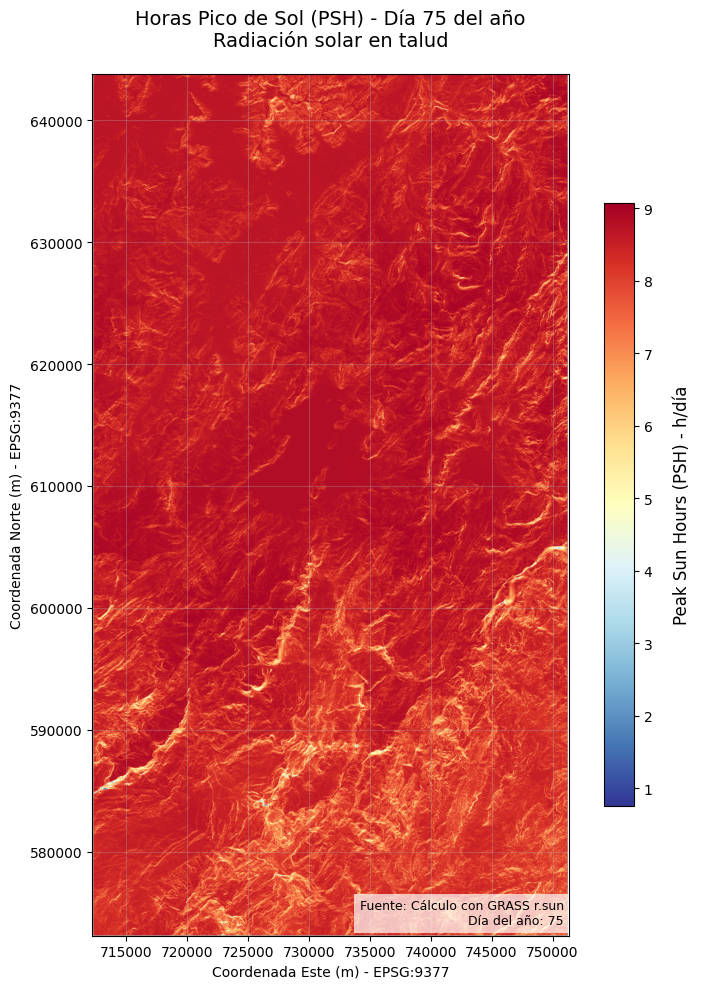

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio

# ==================== CONFIGURACIÓN ====================
PSH_TIF = "../docker/fastapi-qgis/output/radiacion_solar/PSH.tif"

# Nombre del archivo PNG de salida
OUTPUT_PNG = "../docker/fastapi-qgis/output/radiacion_solar/PSH_mapa.png"
# ========================================================

with rasterio.open(PSH_TIF) as src:
    psh_data = src.read(1)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    
    if src.nodata is not None:
        psh_data = np.where(psh_data == src.nodata, np.nan, psh_data)

# ====================== PLOT ======================
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(
    psh_data,
    extent=extent,
    cmap='RdYlBu_r',
    vmin=np.nanmin(psh_data),
    vmax=np.nanmax(psh_data)
)

cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.03)
cbar.set_label('Peak Sun Hours (PSH) - h/día', fontsize=12, rotation=90, labelpad=15)

plt.title("Horas Pico de Sol (PSH) - Día 75 del año\nRadiación solar en talud", 
          fontsize=14, pad=20)

plt.xlabel("Coordenada Este (m) - EPSG:9377")
plt.ylabel("Coordenada Norte (m) - EPSG:9377")

plt.ticklabel_format(style='plain')

ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.text(0.99, 0.01, 
         "Fuente: Cálculo con GRASS r.sun\nDía del año: 75",
         transform=ax.transAxes,
         fontsize=9, ha='right', va='bottom',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()

# ==================== EXPORTAR COMO PNG ====================
plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches='tight')

print(f"✅ Mapa guardado correctamente como:\n{OUTPUT_PNG}")

plt.show()

✅ Mapa guardado correctamente como:
../docker/fastapi-qgis/output/radiacion_solar/Produccion_5kWp_mapa.png


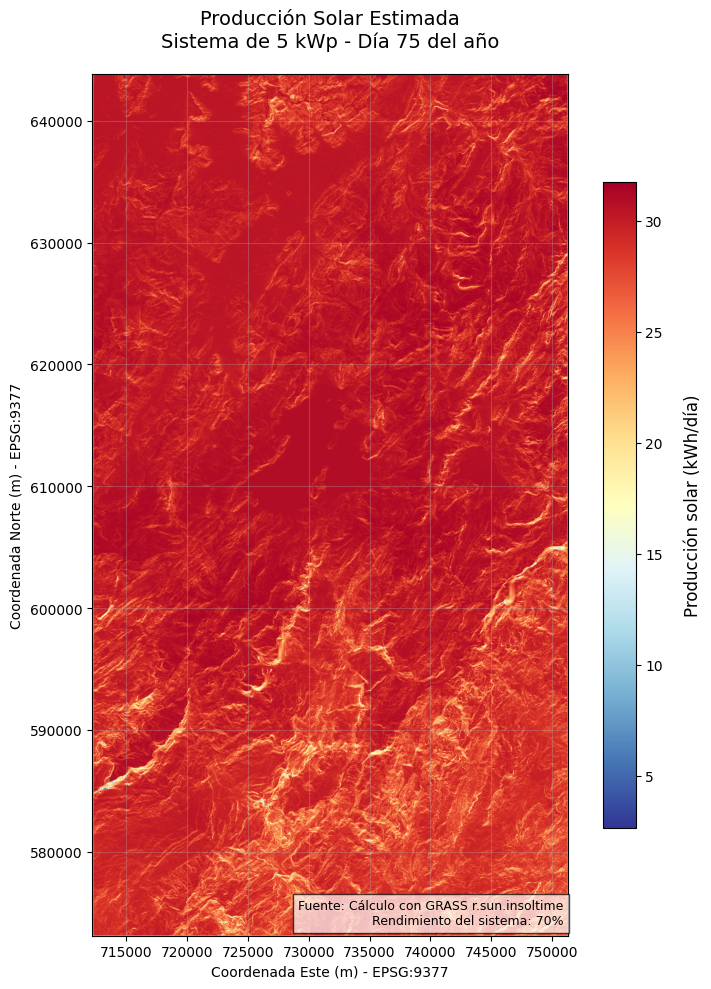

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio

# ==================== CONFIGURACIÓN ====================
PRODUCCION_TIF = "../docker/fastapi-qgis/output/radiacion_solar/Produccion_kWh_dia_5kWp.tif"

# Nombre del archivo PNG de salida
OUTPUT_PNG = "../docker/fastapi-qgis/output/radiacion_solar/Produccion_5kWp_mapa.png"
# ========================================================

with rasterio.open(PRODUCCION_TIF) as src:
    produccion_data = src.read(1)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    
    # Reemplazar nodata por NaN
    if src.nodata is not None:
        produccion_data = np.where(produccion_data == src.nodata, np.nan, produccion_data)

# ====================== PLOT ======================
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(
    produccion_data,
    extent=extent,
    cmap='RdYlBu_r',                    
    vmin=np.nanmin(produccion_data),
    vmax=np.nanmax(produccion_data)
)

cbar = plt.colorbar(im, ax=ax, shrink=0.75, pad=0.03)
cbar.set_label('Producción solar (kWh/día)', fontsize=12, rotation=90, labelpad=15)

plt.title(f"Producción Solar Estimada\nSistema de 5 kWp - Día 75 del año", 
          fontsize=14, pad=20)

plt.xlabel("Coordenada Este (m) - EPSG:9377")
plt.ylabel("Coordenada Norte (m) - EPSG:9377")

plt.ticklabel_format(style='plain')

ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.text(0.99, 0.01, 
         "Fuente: Cálculo con GRASS r.sun.insoltime\nRendimiento del sistema: 70%",
         transform=ax.transAxes,
         fontsize=9, ha='right', va='bottom',
         bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()

# ==================== EXPORTAR COMO PNG ====================
plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches='tight')

print(f"✅ Mapa guardado correctamente como:\n{OUTPUT_PNG}")

plt.show()

Calculo de psh y producción solar estimada para una unidad habitacional con un rendimiento del 70% para el dia 14 de marzo para la zona del centro urbano del municipio Sabana de Torres del departamente de Santander de Colombia

In [1]:
import subprocess

CONTAINER = "fastapi-qgis"
DEM01 = "/app/data/module03/MDT1_68655000_20240525.tif"
DEM_CRS01 = "EPSG:9377"  

SLOPE01 = "/app/output/radiacion_solar/slope01.tif"
ASPECT01 = "/app/output/radiacion_solar/aspect01.tif"
INSOLATION01 = "/app/output/radiacion_solar/insolacion01.tif"
GLOBAL_RADIATION01 = "/app/output/radiacion_solar/radiacion_global_diaria01.tif"

DAY_OF_YEAR01 = 75
TIME_STEP_HOURS01 = 0.25


def run_cmd(step_name, cmd, expected_outputs=()):
    print(f"\n=== {step_name} ===")

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        print("ERROR")
        print(result.stderr)
        raise RuntimeError(f"Falló: {step_name}")

    for output_path in expected_outputs:
        check = subprocess.run(["docker", "exec", CONTAINER, "test", "-f", output_path])
        if check.returncode != 0:
            raise FileNotFoundError(f"No se generó: {output_path}")

    print("OK")


#Asignar CRS al DEM original
assign_crs_cmd = [
    "docker", "exec", CONTAINER,
    "qgis_process", "run", "gdal:assignprojection",
    "--",
    f"INPUT={DEM01}",
    f"CRS={DEM_CRS01}",
    f"OUTPUT={DEM01}",
]

# Pendiente y orientación del talud.
slope_cmd = [
    "docker", "exec", CONTAINER,
    "qgis_process", "run", "grass:r.slope.aspect",
    "--",
    f"elevation={DEM01}",
    f"slope={SLOPE01}",
    f"aspect={ASPECT01}",
]

# Insolación y radiación global diaria. insol_time (h) y glob_rad (Wh/m2/día).
rsun_cmd = [
    "docker", "exec", CONTAINER,
    "qgis_process", "run", "grass:r.sun.insoltime",
    "--",
    f"elevation={DEM01}",
    f"slope={SLOPE01}",
    f"aspect={ASPECT01}",
    f"insol_time={INSOLATION01}",
    f"glob_rad={GLOBAL_RADIATION01}",
    f"day={DAY_OF_YEAR01}",
    f"step={TIME_STEP_HOURS01}",
]

run_cmd("Paso 0 - Asignar CRS al DEM", assign_crs_cmd)
run_cmd("Paso 1 - Calcular slope y aspect", slope_cmd, expected_outputs=(SLOPE01, ASPECT01))
run_cmd("Paso 2 - Calcular insolación y radiación global", rsun_cmd, expected_outputs=(INSOLATION01, GLOBAL_RADIATION01),)


=== Paso 0 - Asignar CRS al DEM ===
OK

=== Paso 1 - Calcular slope y aspect ===
OK

=== Paso 2 - Calcular insolación y radiación global ===
OK


In [6]:
import numpy as np
import rasterio
from rasterio.transform import from_origin
import os

RADIACION_GLOBAL_LOCAL01 = "../docker/fastapi-qgis/output/radiacion_solar/radiacion_global_diaria01.tif"

POTENCIA_SISTEMA_KWP01 = 5.0
RENDIMIENTO_SISTEMA01 = 0.70

OUTPUT_DIR01 = os.path.dirname(RADIACION_GLOBAL_LOCAL01)

with rasterio.open(RADIACION_GLOBAL_LOCAL01) as src:
    radiacion01 = src.read(1).astype("float64")
    profile01 = src.profile.copy()         

    if src.nodata is not None:
        radiacion01[radiacion01 == src.nodata] = np.nan
    
    psh01 = radiacion01 / 1000.0                                 
    produccion01 = psh01 * POTENCIA_SISTEMA_KWP01 * RENDIMIENTO_SISTEMA01           

    # === Guardar mapas ===
    profile01.update(dtype='float32', nodata=np.nan)
    with rasterio.open(os.path.join(OUTPUT_DIR01, "PSH01.tif"), 'w', **profile01) as dst:
        dst.write(psh01.astype('float32'), 1)

    with rasterio.open(os.path.join(OUTPUT_DIR01, "Produccion_kWh_dia_5kWp01.tif"), 'w', **profile01) as dst:
        dst.write(produccion01.astype('float32'), 1)
        
    print("=== MAPAS GENERADOS ===")

radiacion_media01 = np.nanmean(radiacion01)
radiacion_min01 = np.nanmin(radiacion01)
radiacion_max01 = np.nanmax(radiacion01)

psh_media01 = radiacion_media01 / 1000
psh_min01 = radiacion_min01 / 1000
psh_max01 = radiacion_max01 / 1000

produccion_kwh_dia01 = psh_media01 * POTENCIA_SISTEMA_KWP01 * RENDIMIENTO_SISTEMA01

print("=== CÁLCULO DE PSH Y PRODUCCIÓN SOLAR ESTIMADA ===")
print(f"Radiación global media: {radiacion_media01:.2f} Wh/m²/día")
print(f"PSH medio: {psh_media01:.2f} h")
print(f"PSH mínimo: {psh_min01:.2f} h")
print(f"PSH máximo: {psh_max01:.2f} h")
print(f"Producción solar estimada: {produccion_kwh_dia01:.2f} kWh/día")

=== MAPAS GENERADOS ===
=== CÁLCULO DE PSH Y PRODUCCIÓN SOLAR ESTIMADA ===
Radiación global media: 7994.74 Wh/m²/día
PSH medio: 7.99 h
PSH mínimo: 3.24 h
PSH máximo: 8.15 h
Producción solar estimada: 27.98 kWh/día


✅ Mapa guardado correctamente como:
../docker/fastapi-qgis/output/radiacion_solar/PSH_mapa01.png


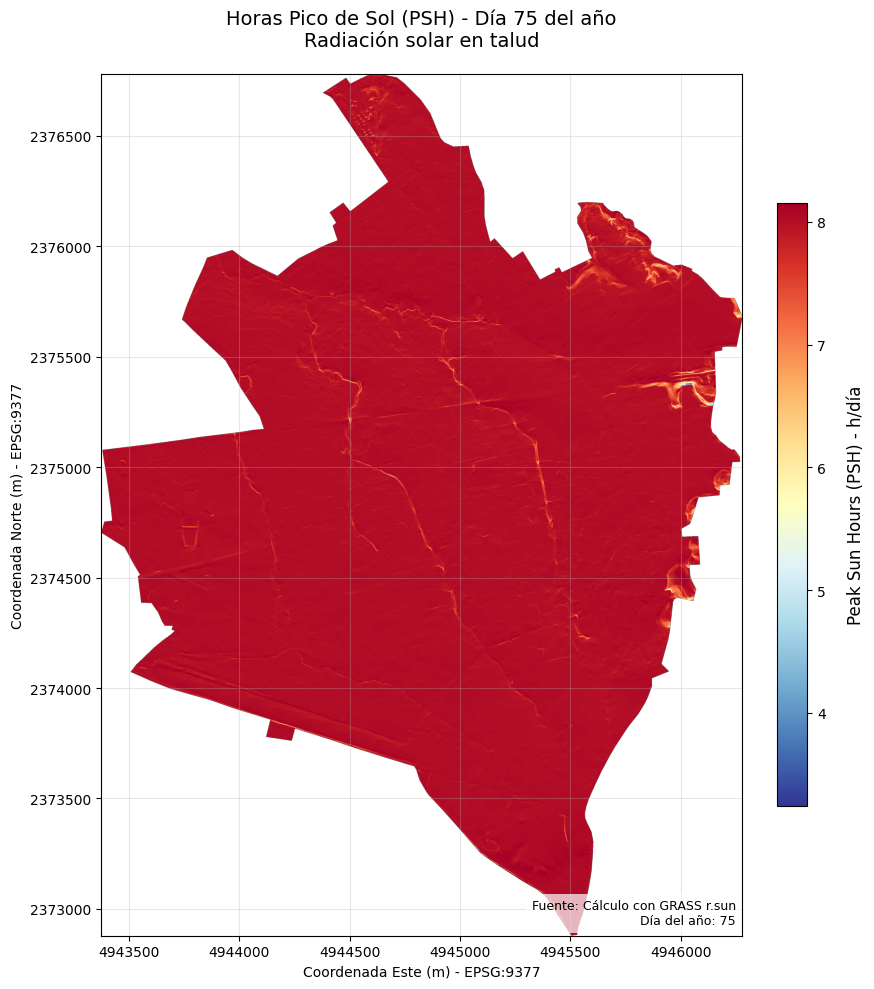

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio

# ==================== CONFIGURACIÓN ====================
PSH_TIF01 = "../docker/fastapi-qgis/output/radiacion_solar/PSH01.tif"

# Nombre del archivo PNG de salida
OUTPUT_PNG01 = "../docker/fastapi-qgis/output/radiacion_solar/PSH_mapa01.png"
# ========================================================

with rasterio.open(PSH_TIF01) as src:
    psh_data01 = src.read(1)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    
    if src.nodata is not None:
        psh_data01 = np.where(psh_data01 == src.nodata, np.nan, psh_data01)

# ====================== PLOT ======================
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(
    psh_data01,
    extent=extent,
    cmap='RdYlBu_r',
    vmin=np.nanmin(psh_data01),
    vmax=np.nanmax(psh_data01)
)

cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.03)
cbar.set_label('Peak Sun Hours (PSH) - h/día', fontsize=12, rotation=90, labelpad=15)

plt.title("Horas Pico de Sol (PSH) - Día 75 del año\nRadiación solar en talud", 
          fontsize=14, pad=20)

plt.xlabel("Coordenada Este (m) - EPSG:9377")
plt.ylabel("Coordenada Norte (m) - EPSG:9377")

plt.ticklabel_format(style='plain')

ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.text(0.99, 0.01, 
         "Fuente: Cálculo con GRASS r.sun\nDía del año: 75",
         transform=ax.transAxes,
         fontsize=9, ha='right', va='bottom',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()

# ==================== EXPORTAR COMO PNG ====================
plt.savefig(OUTPUT_PNG01, dpi=300, bbox_inches='tight')

print(f"✅ Mapa guardado correctamente como:\n{OUTPUT_PNG01}")

plt.show()

✅ Mapa guardado correctamente como:
../docker/fastapi-qgis/output/radiacion_solar/Produccion_5kWp_mapa01.png


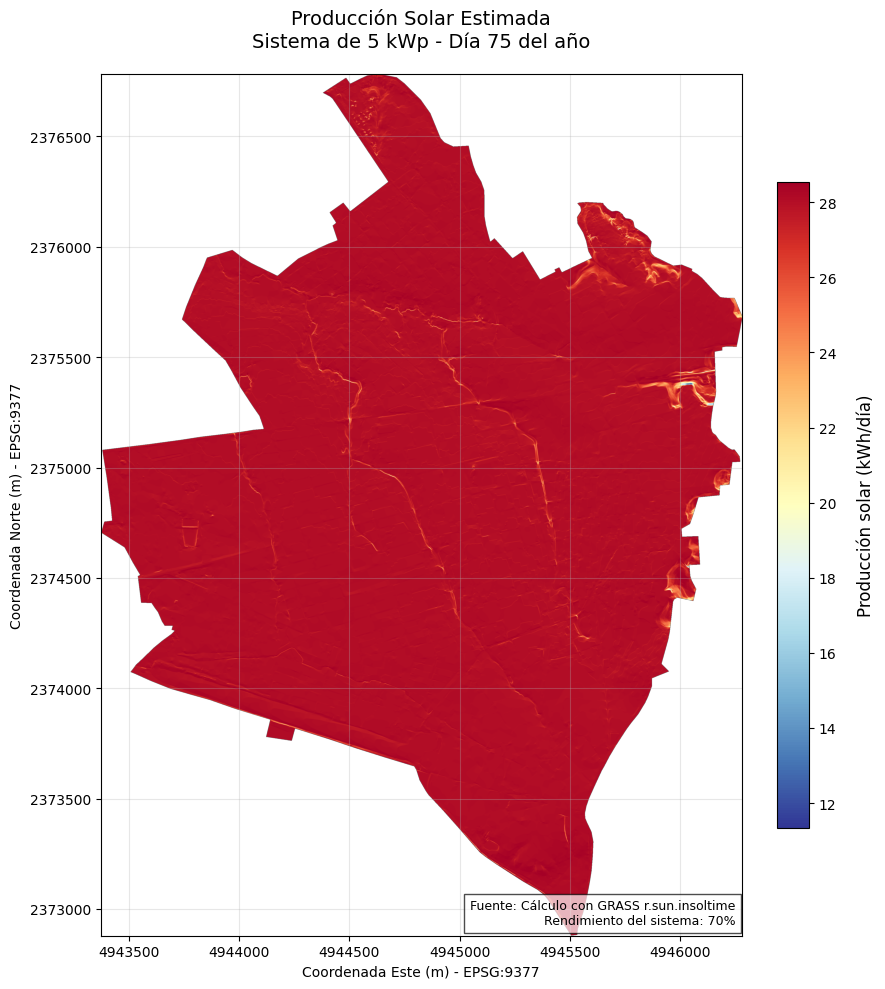

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio

# ==================== CONFIGURACIÓN ====================
PRODUCCION_TIF01 = "../docker/fastapi-qgis/output/radiacion_solar/Produccion_kWh_dia_5kWp01.tif"

# Nombre del archivo PNG de salida
OUTPUT_PNG01 = "../docker/fastapi-qgis/output/radiacion_solar/Produccion_5kWp_mapa01.png"
# ========================================================

with rasterio.open(PRODUCCION_TIF01) as src:
    produccion_data = src.read(1)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    
    # Reemplazar nodata por NaN
    if src.nodata is not None:
        produccion_data = np.where(produccion_data == src.nodata, np.nan, produccion_data)

# ====================== PLOT ======================
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(
    produccion_data,
    extent=extent,
    cmap='RdYlBu_r',                    
    vmin=np.nanmin(produccion_data),
    vmax=np.nanmax(produccion_data)
)

cbar = plt.colorbar(im, ax=ax, shrink=0.75, pad=0.03)
cbar.set_label('Producción solar (kWh/día)', fontsize=12, rotation=90, labelpad=15)

plt.title(f"Producción Solar Estimada\nSistema de 5 kWp - Día 75 del año", 
          fontsize=14, pad=20)

plt.xlabel("Coordenada Este (m) - EPSG:9377")
plt.ylabel("Coordenada Norte (m) - EPSG:9377")

plt.ticklabel_format(style='plain')

ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.text(0.99, 0.01, 
         "Fuente: Cálculo con GRASS r.sun.insoltime\nRendimiento del sistema: 70%",
         transform=ax.transAxes,
         fontsize=9, ha='right', va='bottom',
         bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()

# ==================== EXPORTAR COMO PNG ====================
plt.savefig(OUTPUT_PNG01, dpi=300, bbox_inches='tight')

print(f"✅ Mapa guardado correctamente como:\n{OUTPUT_PNG01}")

plt.show()

- Explicar qué zonas del raster tienen mayor potencial solar y por qué.
- Cómo influyen la pendiente y la orientación del terreno en los resultados.

La radiación solar es trasmitida como una onda de luz, la forma en que esta interactua con los elementos establece el grado de propagación de la radiación en la zona, es de esta manera como zonas con pendientes altas van a generar mayor difusión de la energia y por lo tanto, menor cantidad de radiación solar, lo que se hace evidente al observar las horas sol pico y la producción solar estimada, ya que son las zonas que presentan menor horas sol pico y menor produccion energetica. De manera que zonas con bajas pendientes son favorables para la producción de energia solar, por otra parte, la orientación tiene mayor o menos incidencia dependiendo de varios factores, entre los que estan, el punto de posicion del observador (si encuentras en paralelos cercanos a la linea ecuatorial, tendras menor incidencia en los angulos del sol, no afectandose tanto por la orientación), el mes del año (dado que el sol tiene una posicion para el observador dependiendo del mes del año, dado que cambia su angulo de inclinación con respecto al eje central de la tierra). 

Adicionalmente, en la zona de mayor zoom, es evidente que en vegetación robusta hay una disminusión en la produccion energetica, esto tiene consistencia con la forma en que inciden las ondas de luz al chocar con la vegetación frondosa de los arbustos, lo cual es consistente con el hecho de pendientes fuertes menor producción energetica.
